# imports

In [1]:
import numpy as np
import networkx as nx
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
from scipy import linalg as la
from collections import Counter
from scipy.interpolate import griddata
import matplotlib.colors as mcolors
import time as tm
import pandas as pd
from scipy.optimize import minimize
import pickle
# One more SR for contextual transitions
# Update W to create Omega
# Learn SR between different Omegas - Xi
# Everytime there's a large change in M controlled by uncertainty, then try to change the omega to next predicted one
# The learning error for the SR is the difference between the predicted omega and the computed omega
# a function to predict the current omega from Xi

#a function to take a m-vector with n<m non-zero probabilities as elements and output an index as in metropolis montecarlo:
def choose(vector):
    m  = len(vector)
    indices = np.where(vector != 0)[0]
    if len(indices) != 0:
        elts = vector[vector != 0]
        cumsums = np.cumsum(elts) 
        t = np.random.random()
        k = indices[0]
        if t < cumsums[0]:
            return k
        else:
            for i in range(len(elts)-1):
                if cumsums[i] <= t < cumsums[i+1]:
                    k = indices[i+1]
        return k
    else:
        return np.random.choice(len(vector))
    
def choose_thresholded(vector):
    m  = len(vector)
    indices = np.where(vector != 0)[0]
    if len(indices) != 0:
        elts = vector[vector != 0]
        cumsums = np.cumsum(elts) 
        t = np.random.random()
        k = indices[0]
        if t < cumsums[0]:
            return k
        else:
            for i in range(len(elts)-1):
                if cumsums[i] <= t < cumsums[i+1]:
                    k = indices[i+1]
        return k
    else:
        # else return None
        return None
    
def nextContext(currentContext, Xi):
    context_vec = encoded_contexts[currentContext]
    next_context_vec = np.dot(Xi, context_vec)
    next_context = np.argmax(next_context_vec)
    if next_context == currentContext:
        new_vec = np.delete(next_context_vec, currentContext,0)
        ind = choose(new_vec)
        return np.where(next_context_vec == new_vec[ind])[0][0]
    else:
        return next_context

def is_reward_in_path(mat,state,states):
    state_dict = {state: i for i, state in enumerate(states)}
    state_number = state_dict[state]
    state_numbers = np.array([states.index(s) for s in states])
    onehot = OneHotEncoder(sparse=False)
    encoded_states = onehot.fit_transform(np.array(state_numbers).reshape(len(states),1))
    state_vec = encoded_states[state_number]
    next_vec = np.dot(state_vec,mat)
    next_next_vec = np.dot(next_vec,mat)
    if next_next_vec[4] == 1:
        bool = True
    else:
        bool = False
    # if bool and all the other indices in next_next_vec are 0, return True
    # if not, return False
    if bool and np.sum(next_next_vec) == 1:
        return bool, True
    elif bool and np.sum(next_next_vec) > 1:
        return bool, False 
    else:
        return False, False
    
# given a list of states - memory, a function to update it with the current one: add the current state to the end of memory and remove the first one
def updateMemory(memory, current_state):
    if len(memory) < 10:
        memory.append(current_state)
    else:
        memory.append(current_state)
        memory = memory[1:]
    return memory

def compare_td_error(list,threshold):
    errornorms = np.linalg.norm(list,axis=1)
    if np.linalg.norm(list[-1]) > threshold* np.mean(errornorms):
        return True
    else:
        return False

# give a next state according to the probabilities in the transition matrix
def give_next_state(state,transition_matrix,states):
    #one hot encode the states
    state_numbers = np.array([states.index(s) for s in states])
    onehot_encoder = OneHotEncoder(sparse_output=False)
    encoded_states = onehot_encoder.fit_transform(np.array(state_numbers).reshape(len(states),1))
    next_vec = transition_matrix.dot(encoded_states[states.index(state)])
    next_index = choose(next_vec)
    return states[next_index]

def give_next_state_thresholded(state,transition_matrix,states):
    #one hot encode the states
    onehot_encoder = OneHotEncoder(sparse_output=False)
    encoded_states = onehot_encoder.fit_transform(np.array(states).reshape(len(states),1))
    next_vec = transition_matrix.dot(encoded_states[states.index(state)])
    next_index = choose_thresholded(next_vec)
    if next_index == None:
        return None
    else:
        return states[next_index]

# given a list of context-SRs, and a current SR (thresholded) compare and find the best one
def findright(list,current):
    counts = np.zeros(len(list))
    for i in range(len(list)):
        counts[i] += (current == list[i]).sum()
    candidate = np.random.choice(np.where(counts==np.max(counts))[0])
    return list[candidate], candidate, counts

def normalize(matrix):
    for i in range(len(matrix)):
        indices = np.where(matrix[i,:] != 0)[0]
        if len(indices) != 0:
            matrix[i,indices] = matrix[i,indices]/np.sum(matrix[i,indices])
        else:
            matrix[i,:] = np.zeros(len(matrix[i,:]))
    return matrix

# a function to compute expectation of next state given current state and a transition matrix or causal graph
def expectation(current_state, next_state, transition, time_step, is_causal, time):
    if is_causal:
        time_constant = 0.1*time_step
        if time > time_step*1.01:
            return (1 - np.exp(-(time_step*1.1)/time_constant)) * transition[current_state, next_state] * np.exp(-(time - time_step*1)/time_constant)
        else:
            return (1 - np.exp(-time/time_constant)) * transition[current_state, next_state]
    else:
        time_constant = 0.9*time_step
        if time > time_step*1.01:
            return (1 - np.exp(-(time_step*1.1)/time_constant)) * transition[current_state, next_state] * np.exp(-(time - time_step*1)/time_constant)
        else:
            return (1 - np.exp(-time/time_constant)) * transition[current_state, next_state]


def choice_2step(states, thresholded_successor, actions):
    state_dict = {state: i for i, state in enumerate(states)}
    reward_in_left, only_reward_in_left = is_reward_in_path(thresholded_successor[:,:,0], 'left',states)
    reward_in_right, only_reward_in_right = is_reward_in_path(thresholded_successor[:,:,1], 'right',states)
    if reward_in_left and reward_in_right:
        if only_reward_in_left and not only_reward_in_right:
            next_state = 'left'
            action_index = 0
        elif only_reward_in_right and not only_reward_in_left:
            next_state = 'right'
            action_index = 1
        else:
            next_state = np.random.choice(['left', 'right'])
            action_index = actions.index(next_state)
    elif reward_in_left and not reward_in_right:
        next_state = 'left'
        action_index = 0
    elif reward_in_right and not reward_in_left:
        next_state = 'right'
        action_index = 1
    else:
        next_state = np.random.choice(['left', 'right'])
        action_index = actions.index(next_state)
    return next_state, action_index

# a function to give a choice probability 

def choiceprob_2step(action_index, epsilon):
    prob =  (1 - epsilon)*action_index + epsilon/2
    rand = np.random.random()
    if rand < prob:
        index = 1
    else:
        index = 0
    return prob, index

def inv_logit(x):
    return np.log(x/(1-x))

# function to compute the negative log-likelihood of the choices given the model and the data
def log_likelihood_choices(results,choices,free_choice):
    log_likelihood = 0
    choices_predicted = results[results['free_choice']==True]['choices']
    choices_actual = choices[np.where(free_choice == True)[0]]
    for i in range(len(choices)):
        choice = choices[i]
        choice_prob = results['choice_probs'][i]
        if choice == 1:
            log_likelihood += np.log(choice_prob)
        else:
            log_likelihood += np.log(1 - choice_prob)
    return  -1 * log_likelihood

def logit(x):
    return np.exp(x)/(1 + np.exp(x))


def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size) / window_size, mode='valid')

def compute_gpe(thresh_successor,state_current,state_next,action,states):
    predicted_next = give_next_state_thresholded(state_current,thresh_successor[:,:,action],states)
    state_current_number = states.index(state_current)
    state_next_number = states.index(state_next)
    predicted_next_number = states.index(predicted_next) if predicted_next != None else None
    if predicted_next == state_next and predicted_next != None:
        gpe = 1
    else:
        gpe = thresh_successor[state_current_number,state_next_number,action] - 1
    return gpe

def transform_params(params = [0,0,0,0,0]):
    list = []
    for i in range(len(params)):
        if i != 3:
            list.append(logit(params[i]))
        else:
            list.append(np.exp(params[i]))
    return list

# function to import parameters from the data
def import_data(sample_session):
    free_choice = sample_session['free_choice']
    transitions = sample_session['transitions']
    choices = sample_session['choices']
    outcomes = sample_session['outcomes']
    second_steps = sample_session['second_steps']
    stims = sample_session['stim']
    n_episodes = len(choices)
    return free_choice, transitions, choices, outcomes, second_steps, stims, n_episodes

# function to create a new dataframe with only the rows where the free choice is 1, and the row after that one
def create_frame(results):
    frame = pd.DataFrame(columns=['choices', 'choice_probs', 'second_steps', 'outcomes', 'transitions', 'free_choice', 'stage', 'mov_average', 'stim', 'stim_type','block'])
    for i in range(len(results)-1):
        if results['free_choice'][i] == 1:
            if results['free_choice'][i+1] == 1:
                frame = pd.concat([frame, results.iloc[i:i+2]], axis = 0)
    frame = frame.reset_index(drop=True)
    return frame

def create_counts(frame,transition_states):
    if transition_states == 1:
        total_counts = {'CR': 0,  'RR': 0, 'CU': 0,'RU': 0}
        stay_probs_predicted = {'CR': 0,  'RR': 0,'CU': 0, 'RU': 0}
        stay_counts_actual = {'CR': 0,  'RR': 0,'CU': 0, 'RU': 0}
        for i in range(0,len(frame),2):
            if frame['transitions'][i] == 1 and frame['outcomes'][i] == 1:
                total_counts['CR'] += 1
                if frame['choices'][i] == frame['choices'][i+1]:
                    stay_counts_actual['CR'] += 1
                if frame['choices'][i] == 1:
                    stay_probs_predicted['CR'] += frame['choice_probs'][i+1]
                elif frame['choices'][i] == 0:
                    stay_probs_predicted['CR'] += 1 - frame['choice_probs'][i+1]
            elif frame['transitions'][i] == 1 and frame['outcomes'][i] == 0:
                total_counts['CU'] += 1
                if frame['choices'][i] == frame['choices'][i+1]:
                    stay_counts_actual['CU'] += 1
                if frame['choices'][i] == 1:
                    stay_probs_predicted['CU'] += frame['choice_probs'][i+1]
                elif frame['choices'][i] == 0:
                    stay_probs_predicted['CU'] += 1 - frame['choice_probs'][i+1]
            elif frame['transitions'][i] == 0 and frame['outcomes'][i] == 1:
                total_counts['RR'] += 1
                if frame['choices'][i] == frame['choices'][i+1]:
                    stay_counts_actual['RR'] += 1
                if frame['choices'][i] == 1:
                    stay_probs_predicted['RR'] += frame['choice_probs'][i+1]
                elif frame['choices'][i] == 0:
                    stay_probs_predicted['RR'] += 1 - frame['choice_probs'][i+1]
            elif frame['transitions'][i] == 0 and frame['outcomes'][i] == 0:
                total_counts['RU'] += 1
                if frame['choices'][i] == frame['choices'][i+1]:
                    stay_counts_actual['RU'] += 1
                if frame['choices'][i] == 1:
                    stay_probs_predicted['RU'] += frame['choice_probs'][i+1]
                elif frame['choices'][i] == 0:
                    stay_probs_predicted['RU'] += 1 - frame['choice_probs'][i+1]
        stay_probs_predicted_std = {'CR': 0,  'RR': 0,'CU': 0, 'RU': 0}
        stay_counts_actual_std = {'CR': 0,  'RR': 0,'CU': 0, 'RU': 0}
        for key in stay_probs_predicted:
            stay_probs_predicted[key] = stay_probs_predicted[key]/total_counts[key]
            stay_counts_actual[key] = stay_counts_actual[key]/total_counts[key]
            stay_probs_predicted_std[key] = np.sqrt(stay_probs_predicted[key]*(1-stay_probs_predicted[key]))/total_counts[key]
            stay_counts_actual_std[key] = np.sqrt(stay_counts_actual[key]*(1-stay_counts_actual[key]))/total_counts[key]
        return stay_probs_predicted, stay_counts_actual, stay_probs_predicted_std, stay_counts_actual_std
    elif transition_states == 0:
        total_counts = {'CR': 0,  'RR': 0,'CU': 0, 'RU': 0}
        stay_probs_predicted = {'CR': 0,  'RR': 0,'CU': 0, 'RU': 0}
        stay_counts_actual = {'CR': 0,  'RR': 0, 'CU': 0,'RU': 0}
        for i in range(0,len(frame),2):
            if frame['transitions'][i] == 0 and frame['outcomes'][i] == 1:
                total_counts['CR'] += 1
                if frame['choices'][i] == frame['choices'][i+1]:
                    stay_counts_actual['CR'] += 1
                if frame['choices'][i] == 1:
                    stay_probs_predicted['CR'] += frame['choice_probs'][i+1]
                elif frame['choices'][i] == 0:
                    stay_probs_predicted['CR'] += 1 - frame['choice_probs'][i+1]
            elif frame['transitions'][i] == 0 and frame['outcomes'][i] == 0:
                total_counts['CU'] += 1
                if frame['choices'][i] == frame['choices'][i+1]:
                    stay_counts_actual['CU'] += 1
                if frame['choices'][i] == 1:
                    stay_probs_predicted['CU'] += frame['choice_probs'][i+1]
                elif frame['choices'][i] == 0:
                    stay_probs_predicted['CU'] += 1 - frame['choice_probs'][i+1]
            elif frame['transitions'][i] == 1 and frame['outcomes'][i] == 1:
                total_counts['RR'] += 1
                if frame['choices'][i] == frame['choices'][i+1]:
                    stay_counts_actual['RR'] += 1
                if frame['choices'][i] == 1:
                    stay_probs_predicted['RR'] += frame['choice_probs'][i+1]
                elif frame['choices'][i] == 0:
                    stay_probs_predicted['RR'] += 1 - frame['choice_probs'][i+1]
            elif frame['transitions'][i] == 1 and frame['outcomes'][i] == 0:
                total_counts['RU'] += 1
                if frame['choices'][i] == frame['choices'][i+1]:
                    stay_counts_actual['RU'] += 1
                if frame['choices'][i] == 1:
                    stay_probs_predicted['RU'] += frame['choice_probs'][i+1]
                elif frame['choices'][i] == 0:
                    stay_probs_predicted['RU'] += 1 - frame['choice_probs'][i+1]
        stay_probs_predicted_std = {'CR': 0,  'RR': 0,'CU': 0,'RU': 0}
        stay_counts_actual_std = {'CR': 0,  'RR': 0,'CU': 0, 'RU': 0}
        for key in stay_probs_predicted:
            stay_probs_predicted[key] = stay_probs_predicted[key]/total_counts[key]
            stay_counts_actual[key] = stay_counts_actual[key]/total_counts[key]
            stay_probs_predicted_std[key] = np.sqrt(stay_probs_predicted[key]*(1-stay_probs_predicted[key])/total_counts[key])
            stay_counts_actual_std[key] = np.sqrt(stay_counts_actual[key]*(1-stay_counts_actual[key])/total_counts[key])
        return stay_probs_predicted, stay_counts_actual, stay_probs_predicted_std, stay_counts_actual_std
    
# function to plot the stay probabilities
def plot_stay_probs(stay_probs_predicted, stay_counts_actual, stay_probs_predicted_std, stay_counts_actual_std):
    stay_probs_predicted = pd.Series(stay_probs_predicted)
    stay_probs_predicted_std = pd.Series(stay_probs_predicted_std)
    stay_counts_actual = pd.Series(stay_counts_actual)
    stay_counts_actual_std = pd.Series(stay_counts_actual_std)
    plt.figure(figsize=(5,5))
    stay_probs_predicted.plot(kind = 'bar', yerr = stay_probs_predicted_std, position=0, width=0.25, label = 'predictions')
    stay_counts_actual.plot(kind = 'bar', yerr = stay_counts_actual_std,color = 'red',position=1,width=0.25, label = 'data')
    #remove the top and right spines
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    #plt.axhline(y = 0.5, color = 'black', linestyle = ':')
    plt.title('Stay probabilities predicted vs actual')
    plt.legend()

    return stay_probs_predicted, stay_counts_actual
    

def plot_stay_probs_stim(stay_probs_predicted, stay_counts_actual, stay_probs_predicted_std, stay_counts_actual_std):
    stay_probs_predicted = pd.Series(stay_probs_predicted)
    stay_probs_predicted_std = pd.Series(stay_probs_predicted_std)
    stay_counts_actual = pd.Series(stay_counts_actual)
    stay_counts_actual_std = pd.Series(stay_counts_actual_std)
    plt.figure(figsize=(5,5))
    stay_probs_predicted.plot(kind = 'bar', yerr = stay_probs_predicted_std, position=0, width=0.25, label = 'stim')
    stay_counts_actual.plot(kind = 'bar', yerr = stay_counts_actual_std,color = 'red',position=1,width=0.25, label = 'nostim')
    #remove the top and right spines
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    #plt.axhline(y = 0.5, color = 'black', linestyle = ':')
    plt.title('Stay probabilities stim vs nostim')
    plt.legend()
    
    

    return stay_probs_predicted, stay_counts_actual

# function to plot the choice probs
def plot_choice_probs(results, blocks):
    choice_probs = results['choice_probs']
    choices = results['choices']
    moving_average_choices = moving_average(choices,10)
    block_end_trials = blocks['end_trials']
    choices_new = []
    for i in range(len(choices)):
        if choices[i] == 1:
            choices_new.append(1)
        else:
            choices_new.append(-1)

    # plot the moving average of choice probabilities, and the moving average of choices_new times outcomes
    moving_average_choice_probs = moving_average(choice_probs, 10)
    moving_average_outcomes_side = moving_average(np.multiply(choices_new, outcomes),10)
    plt.figure(figsize=(20,10))
    plt.plot(2*moving_average_choice_probs - 1, label = 'choice probs')
    plt.plot(moving_average_outcomes_side, label = 'outcomes by side')
    #horizontal dashed lines at 0, 0.5, -0.5
    plt.axhline(y = 0, color = 'red', linestyle = ':')
    plt.axhline(y = 0.5, color = 'black', linestyle = ':')
    plt.axhline(y = -0.5, color = 'black', linestyle = ':')
    #vertical lines at the end of each block
    for i in range(len(block_end_trials)):
        plt.axvline(x = block_end_trials[i], color = 'black', linestyle = ':')
    plt.title('Choice probabilities, outcomes by side, and choices')
    plt.legend()
    return moving_average_choice_probs, moving_average_outcomes_side

def get_values_from_graph(reward_list, graph):
    # f_matrix is sum of graph and graph-squared and graph-cubed and so on, 4 powers
    f_matrix = np.zeros((len(reward_list),len(reward_list)))
    for i in range(4):
        f_matrix += np.linalg.matrix_power(graph,i+1)
        # for each non-zero element in f_matrix, set it to 1
    f_matrix[f_matrix != 0] = 1
    # for a given row i in f_matrix, value_list[i] is the sum of rewards of all elements in the row which are 1
    value_list = np.zeros(len(reward_list))
    for i in range(len(reward_list)):
        value_list[i] = np.dot(f_matrix[i,:],reward_list)
    return value_list

def get_values_from_graph(reward_list, graph):
    # f_matrix is sum of graph and graph-squared and graph-cubed and so on, 4 powers
    f_matrix = np.zeros((len(reward_list),len(reward_list)))
    for i in range(4):
        f_matrix += np.linalg.matrix_power(graph,i+1)
        # for each non-zero element in f_matrix, set it to 1
    f_matrix[f_matrix != 0] = 1
    # for a given row i in f_matrix, value_list[i] is the sum of rewards of all elements in the row which are 1
    value_list = np.zeros(len(reward_list))
    for i in range(len(reward_list)):
        value_list[i] = np.dot(f_matrix[i,:],reward_list)
    return value_list

def get_values_from_graph_2(reward_list, graph):
    # f_matrix is sum of graph and graph-squared and graph-cubed and so on, 4 powers
    f_matrix = np.zeros((len(reward_list),len(reward_list)))
    for i in range(4):
        f_matrix += np.linalg.matrix_power(graph,i+1)
        # for each non-zero element in f_matrix, set it to 1
    f_matrix[f_matrix != 0] = 1
    # for a given row i in f_matrix, value_list[i] is the sum of rewards of all elements in the row which are 1
    # add the identity matrix to f_matrix
    f_matrix += np.eye(len(f_matrix))
    value_list = np.zeros(len(reward_list))
    for i in range(len(reward_list)):
        value_list[i] = np.dot(f_matrix[i,:],reward_list)
    return value_list

def get_values_from_graph_3(reward_list, graph):
    # f_matrix is sum of graph and graph-squared and graph-cubed and so on, 4 powers
    f_matrix = np.zeros((len(reward_list),len(reward_list)))
    for i in range(4):
        f_matrix += np.linalg.matrix_power(graph,i+1)
        # for each non-zero element in f_matrix, set it to 1
    #f_matrix[f_matrix != 0] = 1
    # for a given row i in f_matrix, value_list[i] is the sum of rewards of all elements in the row which are 1
    # add the identity matrix to f_matrix
    f_matrix += np.eye(len(f_matrix))
    value_list = np.zeros(len(reward_list))
    for i in range(len(reward_list)):
        value_list[i] = np.dot(f_matrix[i,:],reward_list)
    return value_list


def get_values_from_graph_4(reward_list, graph):
    # f_matrix is sum of graph and graph-squared and graph-cubed and so on, 4 powers
    graph += np.eye(len(graph))
    value_list = np.zeros(len(reward_list))
    for i in range(len(value_list)):
        value_list[i] = np.dot(graph[i,:], reward_list)
    return value_list


def choice_function(T,values):
    value_left = values[0]
    value_right = values[1]
    p_left = 1/(1+np.exp((value_right-value_left)/T))
    return p_left

def choice_function_2(values,variance,T):
    value_left = values[0]
    value_right = values[1]
    # add noise to the values
    numerator = np.random.normal(value_right-value_left,variance)
    p_left = 1/(1+np.exp(numerator/T))
    return p_left

def compare_graphs(graph,theta):
    # subtract theta from graph
    diff_matrix = graph - theta
    changed = False
    # if graph is all zeros, replace it with theta
    #if np.all(graph == 0):
        #graph = theta
    # for each column in diff, if the column has a negative value, replace the column of graph with the corresponding column of theta
    # otherwise, keep the column of graph
    #else:
    for i in range(diff_matrix.shape[1]):
        if np.any(diff_matrix[i,:] < 0):
            graph[i,:] = theta[i,:]
            changed = True
    return graph, changed


    
states = ['right', 'left','up','down','reward','no_reward']
actions = ['right','left']
rewards = [0,0,0,0,1,0]


# a function to generate the stims and free_choice lists - the stim trials are 1s in the stim list, and the free choice trials are 1s in the free_choice list
def generate_stims_freeChoice(n_episodes):
    # start with an array of n_episodes/4 3s
    a = np.full(int(n_episodes/4), 3)
    # add 1 to a random number k of elements in the array, and subtract 1 from some other k elements
    k = np.random.randint(0, int(n_episodes/8))
    # add 1 to k elements
    adds = np.random.choice(int(n_episodes/4), k, replace = False)
    indices = np.arange(int(n_episodes/4))
    #remove the adds from the indices
    removes = np.setdiff1d(indices, adds)
    a[adds] += 1
    # k other indices
    subs = np.random.choice(removes, k, replace = False)
    a[subs] -= 1
    # take all the indices which are in subs out and make a list of indices
    indices = np.setdiff1d(indices, subs)
    # add 1 to k elements
    k = np.random.randint(0, int(len(indices)/2))
    adds = np.random.choice(indices, k, replace = False)
    a[adds] += 1
    # k other indices
    removes = np.setdiff1d(indices, adds)
    subs = np.random.choice(removes, k, replace = False)

    a[subs] -= 1

    # create the stim_type list
    stim_1s = np.ones(int(n_episodes/4))
    # for each element i in stim_1s, add a[i] zeros after it
    stims = []
    for pq in range(len(stim_1s)):
        stims.append(stim_1s[pq])
        for gf in range(a[pq]-1):
            stims.append(0)
    for rtu in range(len(stims)):
        stims[rtu] = int(stims[rtu])
    
    if len(stims) < n_episodes:
        stims = np.append(stims, np.zeros(n_episodes - len(stims)))
    #make a list, free_choice of 1000 zeros
    free_choice = np.zeros(n_episodes)
    # each trial after a stim trial is a free choice trial
    for hty in range(len(stims)):
        if stims[hty] == 1 and hty != n_episodes - 1:
            free_choice[hty+1] = 1

    # of the remaining 750 trials, choose 500 at random to be free choice trials
    remaining_indices = np.where(free_choice == 0)[0]
    free_choice_trials = np.random.choice(remaining_indices, int(n_episodes/2), replace = False)
    free_choice[free_choice_trials] = 1

    # test, see how many trials are 1 in free_choice
    len(np.where(free_choice == 1)[0])
    return stims, free_choice

# set the initial conditions of the SR to be the model-based one for all parameters
# check to see if we can reproduce stimulation effect
states = ['right','left','down','up']
sr_initial = np.zeros((len(states),len(states)))

sr_initial[states.index('right'),states.index('down')] = 1
sr_initial[states.index('left'),states.index('up')] = 1




# new graph compare function such that in graph only has one 1 in each row and column

def compare_graphs_nocon(graph, theta):
    graph_2 = graph.copy()
    for i in range(graph.shape[0]):
        for j in range(graph.shape[1]):
            if theta[i,j] == 1 and graph[i,j] == 0:
                graph_2[i,j] = 1
                #set the rest of the row and column to 0
                for k in range(graph.shape[0]):
                    #if k != j:
                        #graph_2[i,k] = 0
                    if k != i:
                        graph_2[k,j] = 0
    return graph_2



def plot_from_results_2(results, params):
    df = results
    params_df = params
    # Compute whether participant stayed (same choice as last trial)
    df['prev_choice'] = df['choices'].shift(1)
    df['stay'] = (df['choices'] == df['prev_choice']).astype(int)

    # Shift transition and outcome to align with current choice
    df['prev_trans'] = df['transitions'].shift(1)
    df['prev_reward'] = df['outcomes'].shift(1)

    # Drop first trial (no previous data)
    df_clean = df.dropna(subset=['prev_trans', 'prev_reward', 'stay'])

    # Map to condition labels
    def label_condition(row):
        if row['prev_trans'] == 1 and row['prev_reward'] == 1:
            return 'CR'
        elif row['prev_trans'] == 0 and row['prev_reward'] == 1:
            return 'RR'
        elif row['prev_trans'] == 1 and row['prev_reward'] == 0:
            return 'CU'
        else:
            return 'RU'

    df_clean['Condition'] = df_clean.apply(label_condition, axis=1)

    # print the number of trials in each condition
    condition_counts = df_clean['Condition'].value_counts()
    print(condition_counts)

    # Group by condition and compute mean and standard error
    summary = df_clean.groupby('Condition')['stay'].agg(['mean', 'sem']).reset_index()
    summary.columns = ['Condition', 'Stay_Probability', 'SE']

    # Reorder for plotting
    condition_order = ['CR', 'RR', 'CU', 'RU']
    summary['Condition'] = pd.Categorical(summary['Condition'], categories=condition_order, ordered=True)
    summary = summary.sort_values('Condition')
    yerr = summary['SE'].values

    # Plot
    sns.set_style("ticks")
    # use subplots and plot sns.barplot on one side, and to the right, add a box with the parameters
    fig, ax = plt.subplots(1,2, figsize=(10, 5))
    palette = {
        'CR': 'b',  # blue
        'CU': 'b',  # blue
        'RR': 'r',  # orange
        'RU': 'r'   # orange
    }
    ax[0] = sns.barplot(
        data=summary,
        errorbar="se",
        x=summary['Condition'],
        y=summary['Stay_Probability'],
        order=condition_order,
        palette=palette,
        edgecolor='white',
        ax=ax[0],
    )
    # add a box to the right of the plot with params, in ax[1]
    ax[1].axis('off')
    ax[1].add_patch(plt.Rectangle((0.5, 0.5), 0.2, 0.2, fill=True, color='white', alpha=0.5))
    for i in range(len(params_df)):
        ax[1].text(0.5, 0.5 - i * 0.1, params_df.iloc[i]['parameter'] + ': ' + str(params_df.iloc[i]['value']), fontsize=10, ha='center', va='center', transform=ax[1].transAxes)
    # Add error bars
    ax[0].errorbar(summary['Condition'], summary['Stay_Probability'], yerr=yerr, fmt='none', capsize=5, color='black')
    # show the plot

    # Labels
    ax[0].set_title('Human Stay Probabilities by Condition', fontsize=16)
    ax[0].set_ylabel('Stay Probability', fontsize=14)
    ax[0].set_xlabel('')
    ax[0].set_ylim([0.5,1])
    plt.tight_layout()
    plt.show()
    
    

    

    return summary

# sim function

In [2]:
def learnCG_newTaskStructure_with_block_changes(learning_rate_transformed, threshold_transformed, discount_transformed, temperature_transformed, learning_rate_rew_stim_transformed,learning_rate_norew_stim_transformed,learning_rate_rew_nostim_transformed, reward_learning_rate_transformed, stayBias_transformed, n_episodes, free_choice, stims, control_bool):
    learning_rate = 1/(1 + np.exp(-learning_rate_transformed))
    discount = 1/(1 + np.exp(-discount_transformed))
    threshold = 1/(1 + np.exp(-threshold_transformed))
    learning_rate_rew_stim = 1/(1 + np.exp(-learning_rate_rew_stim_transformed))
    learning_rate_norew_stim = 1/(1 + np.exp(-learning_rate_norew_stim_transformed))
    learning_rate_rew_nostim = 1/(1 + np.exp(-learning_rate_rew_nostim_transformed))
    reward_learning_rate = 1/(1 + np.exp(-reward_learning_rate_transformed))
    temperature = np.exp(temperature_transformed)
    stayBias = 1/(1 + np.exp(-stayBias_transformed))
    time_constant = 8
    alpha = 1 - np.exp(-1/time_constant)
    # initialize the states
    states = ['right','left','up','down','up_reward','down_reward','no_reward']
    given_rewards = [0,0,0,0,1,1,0]
    # initialize the successor representation and thresholded successor representation
    successor_representation = np.zeros((len(states),len(states)))
    thresholded_successor = np.zeros((len(states),len(states)))
    thresholded_successor_list = []
    values_list = []
    rewards_list = []
    successor_list = []
    rewards = np.zeros(len(states))
    # block_types - 'balanced' or 'biased_up' or 'biased_down'
    block_types = ['balanced','biased_up','biased_down']
    reward_ps = { 'balanced': 0.5, 'biased_up': 0.8, 'biased_down': 0.2 }
    block_type = 'biased_up'
    block_start_time = 0
    block_change_trigger = 0
    block_change_time = None
    learned_rewards = np.zeros(len(states))
    correct_choices = []
    choices = []
    rewards_up = []
    rewards_down = []
    lrs_outcome = []
    graph_list = []
    results = pd.DataFrame(columns=['choices', 'choice_probs', 'second_steps', 'outcomes', 'transitions', 'free_choice', 'stage', 'mov_average', 'stim', 'stim_type','block'])
    for i in range(n_episodes):
        if i == block_change_time:
            if block_type == 'biased_up':
                block_type = np.random.choice(['biased_down','balanced'])
            elif block_type == 'biased_down':
                block_type = np.random.choice(['biased_up','balanced'])
            else:
                block_type = np.random.choice(['biased_up','biased_down'])
            block_change_trigger = 0
            print(f'Block changed to {block_type} at time {i}')
        free_choice_trial = free_choice[i]
        stim_trial = stims[i] if stims[i] != 'NaN' else 0
        # get the values from the graph
        values = get_values_from_graph_2(learned_rewards,thresholded_successor)
        values_list.append(values.copy())
        value_left = values[1]
        value_right = values[0]
        vlist = [value_left, value_right]
        # get the choice probability
        choice_prob = choice_function(temperature, vlist)
        # add stay bias
        if i > 1 and choices[i-1] == 0:
            choice_prob = choice_prob - stayBias if choice_prob - stayBias > 0 else 0.001
        if i > 1 and choices[i-1] == 1:
            choice_prob = choice_prob + stayBias if choice_prob + stayBias < 1 else 0.999
        # make a choice
        choice = np.random.choice([0,1], p = [1 - choice_prob, choice_prob])
        choices.append(choice)
        # based on the block type, compute the moving average of performance
        # in balanced blocks, there is no correct choice so moving average is set to zero
        # in biased_up blocks, the correct choice is to pick left so correct_choice = 1 if choice == 1
        # in biased_down blocks, the correct choice is to pick right so correct_choice = 1 if choice == 0
        if block_type == 'balanced':
            correct_choice = 0
        elif block_type == 'biased_up':
            correct_choice = 1 if choice == 1 and free_choice_trial == 1 else 0
        elif block_type == 'biased_down':
            correct_choice = 1 if choice == 0 and free_choice_trial == 1 else 0
        if i == block_change_time:
            moving_average = 0
            print(f'Moving average reset to 0 at time {i}')
        if free_choice_trial == 1:
            correct_choices.append(correct_choice)
            # compute the moving average of performance as exponential moving average with time constant of 8 correct choices
            if i == 0:
                moving_average = correct_choice
            else:
                moving_average = alpha * correct_choice + (1 - alpha) * moving_average
        else:
        # else, set the moving average to the previous value unless it's the beginning of the block
            # if it's the beginning of the block, set the moving average to 0
            if i == block_start_time:
                moving_average = 0
            else:
                moving_average = correct_choices[-1] if len(correct_choices) > 0 else 0
        # get the current state based on the choice and free_choice_trial
        if choice == 0 and free_choice_trial == 1:
            current_state = 'right' 
            action_index = 0
        elif choice == 1 and free_choice_trial == 1:
            current_state = 'left'
            action_index = 1
        elif free_choice_trial == 0:
            choice = np.random.choice([0,1])
            if choice == 0:
                current_state = 'right'
                action_index = 0
            else:
                current_state = 'left'
                action_index = 1
        # get the next state based on the current state
        if current_state == 'right':
            next_state = np.random.choice(['down','up'], p = [0.8,0.2])
            if next_state == 'down':
                second_step = 0
                transition = 1
            else:
                second_step = 1
                transition = 0
        else:
            next_state = np.random.choice(['down','up'], p = [0.2,0.8])
            if next_state == 'down':
                second_step = 0
                transition = 0
            else:
                second_step = 1
                transition = 1
        # get the state numbers 
        state_number = states.index(current_state)
        next_state_number = states.index(next_state)
        # print(f'Current state: {current_state}, Next state: {next_state}, Next state number: {next_state_number}, State number: {state_number}')
        # reward learning
        learned_rewards[next_state_number] = learned_rewards[next_state_number]*(1- reward_learning_rate) + reward_learning_rate*given_rewards[next_state_number]
        # get the value of the next state
        values = get_values_from_graph_2(learned_rewards,thresholded_successor)
        if values[next_state_number] > 0.5:
            lr = learning_rate_rew_nostim
        else:
            lr = learning_rate
        # update the successor representation
        td_error = np.eye(len(states))[next_state_number,:] - successor_representation[state_number,:]
        # print(f'TD error: {td_error}')
        successor_representation[state_number,:] = successor_representation[state_number,:] + lr * td_error
        #print(f'Successor representation: {successor_representation}')
        # threshold the successor representation
        thresholded_successor= successor_representation.copy()
        thresholded_successor[thresholded_successor < threshold] = 0
        thresholded_successor[thresholded_successor >= threshold] = 1
        #print(f'Thresholded successor representation: {thresholded_successor}')
        # update the graph
        graph = thresholded_successor.copy()
        current_state = next_state
        # get the outcome based on the block type
        if block_type == 'balanced':
            outcome = np.random.choice([0,1], p = [0.5,0.5])
        elif block_type == 'biased_up' and current_state == 'down':
            outcome = np.random.choice([0,1], p = [0.8,0.2])
        elif block_type == 'biased_up' and current_state == 'up':
            outcome = np.random.choice([0,1], p = [0.2,0.8])
        elif block_type == 'biased_down' and current_state == 'down':
            outcome = np.random.choice([0,1], p = [0.2,0.8])
        elif block_type == 'biased_down' and current_state == 'up':
            outcome = np.random.choice([0,1], p = [0.8,0.2])
        if outcome == 1 and current_state == 'up':
            next_state = 'up_reward'
            rewards_up.append(1)
        elif outcome == 1 and current_state == 'down':
            next_state = 'down_reward'
            rewards_down.append(1)
        else:
            next_state = 'no_reward'

        state_number = states.index(current_state)
        next_state_number = states.index(next_state)
        learned_rewards = learned_rewards*(1 - reward_learning_rate)
        learned_rewards[states.index(next_state)] += reward_learning_rate*given_rewards[states.index(next_state)]

        # get the value of the next state
        values = get_values_from_graph_2(learned_rewards,graph)
        # if control_bool == 0:
        #     if values[states.index(next_state)] > 0.5 and stim_trial == 1:
        #         lr = learning_rate_rew_stim
        #     elif values[states.index(next_state)] > 0.5 and stim_trial == 0:
        #         lr = learning_rate_rew_nostim
        #     elif values[states.index(next_state)] <= 0.5 and stim_trial == 1:
        #         lr = learning_rate_norew_stim
        #     elif values[states.index(next_state)] <= 0.5 and stim_trial == 0:
        #         lr = learning_rate
        # else:
        #     if values[states.index(next_state)] > 0.5 and stim_trial == 1:
        #         lr = learning_rate_rew_nostim
        #     elif values[states.index(next_state)] > 0.5 and stim_trial == 0:
        #         lr = learning_rate_rew_nostim
        #     elif values[states.index(next_state)] <= 0.5 and stim_trial == 1:
        #         lr = learning_rate
        #     elif values[states.index(next_state)] <= 0.5 and stim_trial == 0:
        #         lr = learning_rate
        if control_bool == 0:
            if outcome == 1 and stim_trial == 1:
                lr = learning_rate_rew_stim
            elif outcome == 1 and stim_trial == 0:
                lr = learning_rate_rew_nostim
            elif outcome == 0 and stim_trial == 1:
                lr = learning_rate_norew_stim
            elif outcome == 0 and stim_trial == 0:
                lr = learning_rate
        else:
            if outcome == 1 and stim_trial == 1:
                lr = learning_rate_rew_nostim
            elif outcome == 1 and stim_trial == 0:
                lr = learning_rate_rew_nostim
            elif outcome == 0 and stim_trial == 1:
                lr = learning_rate
            elif outcome == 0 and stim_trial == 0:
                lr = learning_rate

        lrs_outcome.append(lr)

        td_error = np.eye(len(states))[next_state_number,:] - successor_representation[state_number,:]
        successor_representation[state_number,:] = successor_representation[state_number,:] + lr * td_error
        # print(f'Successor representation: {successor_representation}')
        thresholded_successor = successor_representation.copy()
        thresholded_successor[thresholded_successor < threshold] = 0
        thresholded_successor[thresholded_successor >= threshold] = 1
        #print(f'Thresholded successor representation: {thresholded_successor}')
        graph = thresholded_successor.copy()
        #print(f'Graph: {graph}')

        # in biased block, detect the first time the moving average crosses the threshold of 0.75
        if block_type != 'balanced' and moving_average > 0.75 and block_change_trigger == 0:
            block_change_trigger = 1
            block_change_time = i + 10
            print(f'Block change time set to {block_change_time} and threshold crossed at {i}')
        if block_type == 'balanced' and block_change_trigger == 0:
            block_change_trigger = 1
            block_change_time = i + 30
        # if the block change time is reached, change the block type
        
        # append the trial result
        results = pd.concat([results, pd.DataFrame({'choices': choice, 'choice_probs': choice_prob, 'second_steps': second_step, 'outcomes': outcome, 'transitions': transition, 'free_choice': free_choice_trial, 'stage': 4.7, 'mov_average': moving_average, 'stim': stim_trial, 'stim_type': 'outcome_cue', 'block': block_type}, index=[0])],axis=0, ignore_index=True)
        thresholded_successor_list.append(thresholded_successor)
        graph_list.append(graph.copy())
        successor_list.append(successor_representation.copy())
        rewards_list.append(learned_rewards.copy())

    return results, thresholded_successor_list, graph_list, values_list, rewards_list, successor_list










# plot stay probs

In [4]:
stims, free_choice = generate_stims_freeChoice(2000)
len(stims[stims == 1]), len(stims[stims == 0])
len(free_choice[free_choice == 1]), len(free_choice[free_choice == 0])

(1500, 500)

In [5]:
learning_rate = inv_logit(0.1)
discount = inv_logit(0.4)
threshold = inv_logit(0.6)
temperature = np.log(0.3)
learning_rate_rew_stim = inv_logit(0.7)
learning_rate_norew_stim = inv_logit(0.3)
learning_rate_rew_nostim = inv_logit(0.2)
reward_learning_rate = inv_logit(0.5)
stay_bias = inv_logit(0.4)
n_episodes = 20000
stims, free_choice = generate_stims_freeChoice(n_episodes)
#stims = np.zeros(n_episodes)
#block_type = 'balanced'
results_stim, thresholded_successor_list_stim, graph_list_stim, value_stim, rewards_stim, successor_list = learnCG_newTaskStructure_with_block_changes(learning_rate, threshold, discount,temperature, learning_rate_rew_stim, learning_rate_norew_stim, learning_rate_rew_nostim, reward_learning_rate, stay_bias, n_episodes, free_choice, stims, 0)
results_control, thresholded_successor_list_control, graph_list_control, value_control, rewards_control, lrs_outcome = learnCG_newTaskStructure_with_block_changes(learning_rate, threshold, discount, temperature, learning_rate_rew_stim, learning_rate_norew_stim, learning_rate_rew_nostim, reward_learning_rate, stay_bias, n_episodes, free_choice, stims, 1)

/var/folders/h8/06sfgt5s5q7d0d67rtrpxbt40000gp/T/ipykernel_59777/1698492714.py:238: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame({'choices': choice, 'choice_probs': choice_prob, 'second_steps': second_step, 'outcomes': outcome, 'transitions': transition, 'free_choice': free_choice_trial, 'stage': 4.7, 'mov_average': moving_average, 'stim': stim_trial, 'stim_type': 'outcome_cue', 'block': block_type}, index=[0])],axis=0, ignore_index=True)


Block change time set to 34 and threshold crossed at 24
Block changed to biased_down at time 34
Moving average reset to 0 at time 34
Block change time set to 46 and threshold crossed at 36
Block changed to biased_up at time 46
Moving average reset to 0 at time 46
Block change time set to 85 and threshold crossed at 75
Block changed to balanced at time 85
Moving average reset to 0 at time 85
Block changed to biased_down at time 115
Moving average reset to 0 at time 115
Block change time set to 130 and threshold crossed at 120
Block changed to biased_up at time 130
Moving average reset to 0 at time 130
Block change time set to 148 and threshold crossed at 138
Block changed to balanced at time 148
Moving average reset to 0 at time 148
Block changed to biased_down at time 178
Moving average reset to 0 at time 178
Block change time set to 191 and threshold crossed at 181
Block changed to balanced at time 191
Moving average reset to 0 at time 191
Block changed to biased_up at time 221
Moving

/var/folders/h8/06sfgt5s5q7d0d67rtrpxbt40000gp/T/ipykernel_59777/1698492714.py:238: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame({'choices': choice, 'choice_probs': choice_prob, 'second_steps': second_step, 'outcomes': outcome, 'transitions': transition, 'free_choice': free_choice_trial, 'stage': 4.7, 'mov_average': moving_average, 'stim': stim_trial, 'stim_type': 'outcome_cue', 'block': block_type}, index=[0])],axis=0, ignore_index=True)


Block changed to biased_up at time 573
Moving average reset to 0 at time 573
Block change time set to 586 and threshold crossed at 576
Block changed to balanced at time 586
Moving average reset to 0 at time 586
Block changed to biased_down at time 616
Moving average reset to 0 at time 616
Block change time set to 639 and threshold crossed at 629
Block changed to biased_up at time 639
Moving average reset to 0 at time 639
Block change time set to 677 and threshold crossed at 667
Block changed to biased_down at time 677
Moving average reset to 0 at time 677
Block change time set to 705 and threshold crossed at 695
Block changed to biased_up at time 705
Moving average reset to 0 at time 705
Block change time set to 720 and threshold crossed at 710
Block changed to biased_down at time 720
Moving average reset to 0 at time 720
Block change time set to 750 and threshold crossed at 740
Block changed to biased_up at time 750
Moving average reset to 0 at time 750
Block change time set to 775 an

/var/folders/h8/06sfgt5s5q7d0d67rtrpxbt40000gp/T/ipykernel_59777/1515025838.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  subset_rr_stim_withnext = pd.concat([subset_rr_stim_withnext, results_stim.iloc[row:row+2,:]], axis=0)
/var/folders/h8/06sfgt5s5q7d0d67rtrpxbt40000gp/T/ipykernel_59777/1515025838.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  subset_rr_nostim_withnext = pd.concat([subset_rr_nostim_withnext, results_stim.iloc[row:row+2,:]], axis=0)


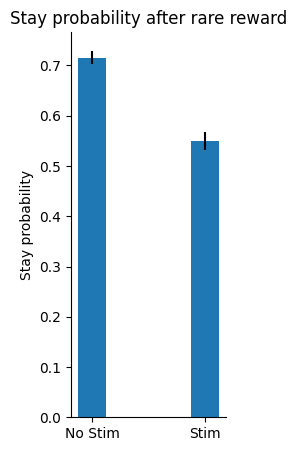

In [6]:
# only the trials for which outcome and stim are 1, and transitions is 0
from scipy.stats import permutation_test
subset_rr_stim = results_stim[(results_stim['outcomes'] == 1) & (results_stim['stim'] == 1) & (results_stim['transitions'] == 0) & (results_stim['block'] == 'balanced') ]
subset_rr_nostim = results_stim[(results_stim['outcomes'] == 1) & (results_stim['stim'] == 0) & (results_stim['transitions'] == 0) & (results_stim['block'] == 'balanced') ]
# for each row of subset_rr_stim, append the row after it from results_stim and put both rows in a dataframe
# for each row of subset_rr_nostim, append the row after it from results_stim and put both rows in a dataframe
subset_rr_stim_withnext = pd.DataFrame(columns=['choices', 'choice_probs', 'second_steps', 'outcomes', 'transitions', 'free_choice', 'stage', 'mov_average', 'stim', 'stim_type','block'])
subset_rr_nostim_withnext = pd.DataFrame(columns=['choices', 'choice_probs', 'second_steps', 'outcomes', 'transitions', 'free_choice', 'stage', 'mov_average', 'stim', 'stim_type','block'])
for i in range(len(subset_rr_stim)):
    row = subset_rr_stim.index[i]
    subset_rr_stim_withnext = pd.concat([subset_rr_stim_withnext, results_stim.iloc[row:row+2,:]], axis=0)
for i in range(len(subset_rr_nostim)):
    row = subset_rr_nostim.index[i]
    subset_rr_nostim_withnext = pd.concat([subset_rr_nostim_withnext, results_stim.iloc[row:row+2,:]], axis=0)


# compute the stay probabilities for the subset_rr_stim_withnext and subset_rr_nostim_withnext
k=0
stay_prob_list_rr_stim = []
while k <= len(subset_rr_stim_withnext)-1:
    choice = subset_rr_stim_withnext.iloc[k]['choices']
    free_choice = subset_rr_stim_withnext.iloc[k+1]['free_choice']
    if choice == 0 and free_choice == 1:
        stay_prob_list_rr_stim.append(1 - subset_rr_stim_withnext.iloc[k+1]['choice_probs'])
    elif choice == 1 and free_choice == 1:
        stay_prob_list_rr_stim.append(subset_rr_stim_withnext.iloc[k+1]['choice_probs'])
    k += 2


k=0
stay_prob_list_rr_nostim = []
while k <= len(subset_rr_nostim_withnext)-2:
    choice = subset_rr_nostim_withnext.iloc[k]['choices']
    if choice == 0 and subset_rr_nostim_withnext.iloc[k+1]['free_choice'] == 1:
        stay_prob_list_rr_nostim.append(1 - subset_rr_nostim_withnext.iloc[k+1]['choice_probs'])
    elif choice == 1 and subset_rr_nostim_withnext.iloc[k+1]['free_choice'] == 1:
        stay_prob_list_rr_nostim.append(subset_rr_nostim_withnext.iloc[k+1]['choice_probs'])
    k += 2

stay_prob_stim = np.mean(stay_prob_list_rr_stim)
stay_prob_stim_error = np.std(stay_prob_list_rr_stim)/np.sqrt(len(stay_prob_list_rr_stim))
stay_prob_nostim = np.mean(stay_prob_list_rr_nostim)
stay_prob_nostim_error = np.std(stay_prob_list_rr_nostim)/np.sqrt(len(stay_prob_list_rr_nostim))

# do a permutation test
stay_prob_list_rr_stim = np.array(stay_prob_list_rr_stim)
stay_prob_list_rr_nostim = np.array(stay_prob_list_rr_nostim)
def statistic(data1, data2):
    return np.mean(data1) - np.mean(data2)

observed_statistic = statistic(stay_prob_list_rr_stim, stay_prob_list_rr_nostim)
p_value = permutation_test((stay_prob_list_rr_stim, stay_prob_list_rr_nostim), statistic).pvalue


plt.figure(figsize=(2,5))
plt.bar(['No Stim','Stim'],[stay_prob_nostim,stay_prob_stim],yerr=[stay_prob_nostim_error,stay_prob_stim_error],width=0.25)
plt.ylabel('Stay probability')
plt.title('Stay probability after rare reward')
# remove the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# add significance stars

plt.show()

In [7]:
p_value

np.float64(0.0002)